# Notebook 13 — Robustness Variants

Generates alternative operationalisations for robustness checks:
- **Part 1**: Rolling 5-year arms stock vs. annual flow
- **Part 2**: Mean vs. sum aggregation for the economic neo-colonial score
- **Part 3**: Save enriched monadic panel

Inputs:
- `../data/merged/panel_monadic_1992_2024.csv`
- `../data/merged/dyadic_panel_1992_2024_oda_capped_log.csv`

Outputs:
- `../outputs/limitations/arms_flow_vs_stock.png`
- `../outputs/limitations/econ_score_sum_vs_mean.png`
- `../outputs/limitations/econ_score_sum_vs_mean_scatter.png`
- `../data/merged/panel_monadic_enriched_1992_2024.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Shared plot style
CREAM = '#F5F2EE'
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.facecolor': CREAM,
    'figure.facecolor': CREAM,
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

MUTED = ['#6A8EAE', '#C07A5A']   # blue, terracotta

## Part 1 — Rolling 5-Year Arms Stock

In [2]:
panel = pd.read_csv('../data/merged/panel_monadic_1992_2024.csv')
print(f'Monadic panel loaded: {panel.shape}')
panel.head(3)

Monadic panel loaded: (6358, 13)


,recipient_iso3,year,arms_tiv_total,oda_total,econ_neocol_score_total,colonial_tie_flag,journalist_killings,gdp_per_capita,gdp_per_capita_log,population,population_log,armed_conflict,conflict_intensity
0,ABW,1992,0.0,29.85,0.0,0,0,13892.605143,9.539112,69005.0,11.141934,0.0,0.0
1,ABW,1993,0.0,22.97,0.0,0,0,14700.959808,9.595668,73685.0,11.207555,0.0,0.0
2,ABW,1994,0.0,15.93,0.0,0,0,16055.287787,9.683794,77595.0,11.259258,0.0,0.0


In [3]:
# Sort before rolling so the window is chronologically correct
panel = panel.sort_values(['recipient_iso3', 'year']).reset_index(drop=True)

panel['arms_tiv_stock_5yr'] = (
    panel.groupby('recipient_iso3')['arms_tiv_total']
    .transform(lambda x: x.rolling(5, min_periods=1).sum())
)

print('Rolling stock computed.')
panel[['recipient_iso3', 'year', 'arms_tiv_total', 'arms_tiv_stock_5yr']].head(10)

Rolling stock computed.


,recipient_iso3,year,arms_tiv_total,arms_tiv_stock_5yr
0,ABW,1992,0.0,0.0
1,ABW,1993,0.0,0.0
2,ABW,1994,0.0,0.0
3,ABW,1995,0.0,0.0
4,ABW,1996,0.0,0.0
5,ABW,1997,0.0,0.0
6,ABW,1998,0.0,0.0
7,ABW,1999,0.0,0.0
8,AFG,1992,0.0,0.0
9,AFG,1993,0.0,0.0


In [4]:
# Summary stats — flow vs stock
print('=== arms_tiv_total (annual flow) ===')
print(panel['arms_tiv_total'].describe().round(3))
print()
print('=== arms_tiv_stock_5yr (5-year rolling sum) ===')
print(panel['arms_tiv_stock_5yr'].describe().round(3))

=== arms_tiv_total (annual flow) ===
count    6358.000
mean      131.946
std       376.328
min         0.000
25%         0.000
50%         3.000
75%        68.160
max      5271.930
Name: arms_tiv_total, dtype: float64

=== arms_tiv_stock_5yr (5-year rolling sum) ===
count     6358.000
mean       612.790
std       1620.777
min          0.000
25%          0.000
50%         34.900
75%        411.238
max      19475.000
Name: arms_tiv_stock_5yr, dtype: float64


In [5]:
# Pearson correlation between flow and stock
r, p = stats.pearsonr(
    panel['arms_tiv_total'].fillna(0),
    panel['arms_tiv_stock_5yr'].fillna(0)
)
print(f'Pearson r (flow vs stock): {r:.4f}  (p={p:.4g})')

Pearson r (flow vs stock): 0.8694  (p=0)


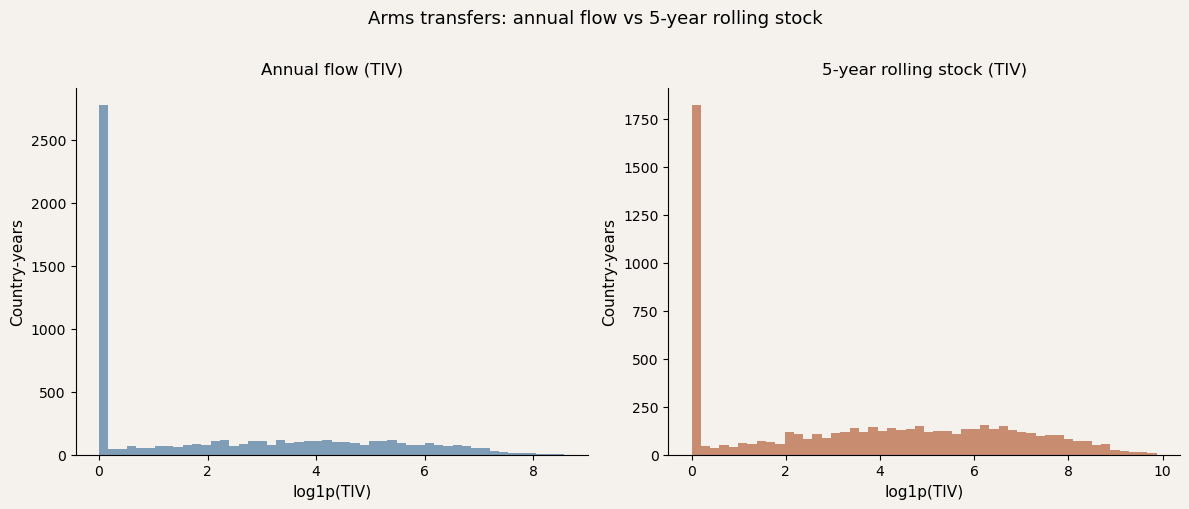

Saved: ../outputs/limitations/arms_flow_vs_stock.png


In [6]:
# Side-by-side distribution plot — log1p scale for readability
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(CREAM)

for ax, col, label, color in zip(
    axes,
    ['arms_tiv_total', 'arms_tiv_stock_5yr'],
    ['Annual flow (TIV)', '5-year rolling stock (TIV)'],
    MUTED
):
    vals = np.log1p(panel[col].fillna(0))
    ax.hist(vals, bins=50, color=color, alpha=0.85, edgecolor='none')
    ax.set_xlabel('log1p(TIV)', fontsize=11)
    ax.set_ylabel('Country-years', fontsize=11)
    ax.set_title(label, fontsize=12, pad=10)
    ax.set_facecolor(CREAM)
    ax.tick_params(labelsize=10)

fig.suptitle('Arms transfers: annual flow vs 5-year rolling stock', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/limitations/arms_flow_vs_stock.png', dpi=150, bbox_inches='tight',
            facecolor=CREAM)
plt.show()
print('Saved: ../outputs/limitations/arms_flow_vs_stock.png')

## Part 2 — Mean Alternative for Economic Neo-Colonial Score

In [7]:
dyadic = pd.read_csv('../data/merged/dyadic_panel_1992_2024_oda_capped_log.csv')
print(f'Dyadic panel loaded: {dyadic.shape}')
dyadic.head(3)

Dyadic panel loaded: (115640, 15)


,sender_iso3,recipient_iso3,year,arms_tiv,bilateral_oda,econ_neocol_score,colonial_tie,journalist_killings,gdp_per_capita,gdp_per_capita_log,population,population_log,armed_conflict,conflict_intensity,econ_neocol_score_log
0,ABW,ISR,1996,17.80,NaN,NaN,0,0,20224.278908,9.914639,5692000.0,15.554572,1.0,1.0,NaN
1,AGO,CIV,2002,1.72,NaN,0.000000e+00,0,0,967.815864,6.875042,18654771.0,16.741612,1.0,1.0,0.000000
2,ALB,BFA,2011,1.20,NaN,7.020872e-12,0,0,725.024768,6.586206,16661908.0,16.628636,0.0,0.0,0.006996


In [8]:
# Compute per-recipient mean of log econ score across senders
econ_mean = (
    dyadic
    .groupby(['recipient_iso3', 'year'])['econ_neocol_score_log']
    .mean()
    .reset_index()
    .rename(columns={'econ_neocol_score_log': 'econ_neocol_score_mean'})
)

print(f'Mean score table: {econ_mean.shape}')
econ_mean.head()

Mean score table: (6358, 3)


,recipient_iso3,year,econ_neocol_score_mean
0,ABW,1992,NaN
1,ABW,1993,NaN
2,ABW,1994,NaN
3,ABW,1995,NaN
4,ABW,1996,NaN


In [9]:
# Merge onto monadic panel (left join — keep all monadic rows)
panel = panel.merge(econ_mean, on=['recipient_iso3', 'year'], how='left')

print(f'Panel after merge: {panel.shape}')
print(f'econ_neocol_score_mean missing: {panel["econ_neocol_score_mean"].isna().sum()} rows')
panel[['recipient_iso3', 'year', 'econ_neocol_score_total', 'econ_neocol_score_mean']].head(6)

Panel after merge: (6358, 15)
econ_neocol_score_mean missing: 2262 rows


,recipient_iso3,year,econ_neocol_score_total,econ_neocol_score_mean
0,ABW,1992,0.0,NaN
1,ABW,1993,0.0,NaN
2,ABW,1994,0.0,NaN
3,ABW,1995,0.0,NaN
4,ABW,1996,0.0,NaN
5,ABW,1997,0.0,NaN


In [10]:
# Summary stats — sum vs mean
print('=== econ_neocol_score_total (sum across senders) ===')
print(panel['econ_neocol_score_total'].describe().round(4))
print()
print('=== econ_neocol_score_mean (mean across senders, log scale) ===')
print(panel['econ_neocol_score_mean'].describe().round(4))

=== econ_neocol_score_total (sum across senders) ===
count    6358.0000
mean       22.3106
std        24.5076
min         0.0000
25%         0.0000
50%         9.8382
75%        44.0258
max       101.3676
Name: econ_neocol_score_total, dtype: float64

=== econ_neocol_score_mean (mean across senders, log scale) ===
count    4096.0000
mean        1.7974
std         0.8510
min         0.0000
25%         1.3098
50%         1.7984
75%         2.2869
max         6.3444
Name: econ_neocol_score_mean, dtype: float64


In [11]:
# Pearson correlation — restrict to rows where both are non-null
both_valid = panel[['econ_neocol_score_total', 'econ_neocol_score_mean']].dropna()
r2, p2 = stats.pearsonr(both_valid['econ_neocol_score_total'], both_valid['econ_neocol_score_mean'])
print(f'Pearson r (sum vs mean): {r2:.4f}  (p={p2:.4g})  n={len(both_valid):,}')

Pearson r (sum vs mean): 0.3765  (p=4.036e-138)  n=4,096


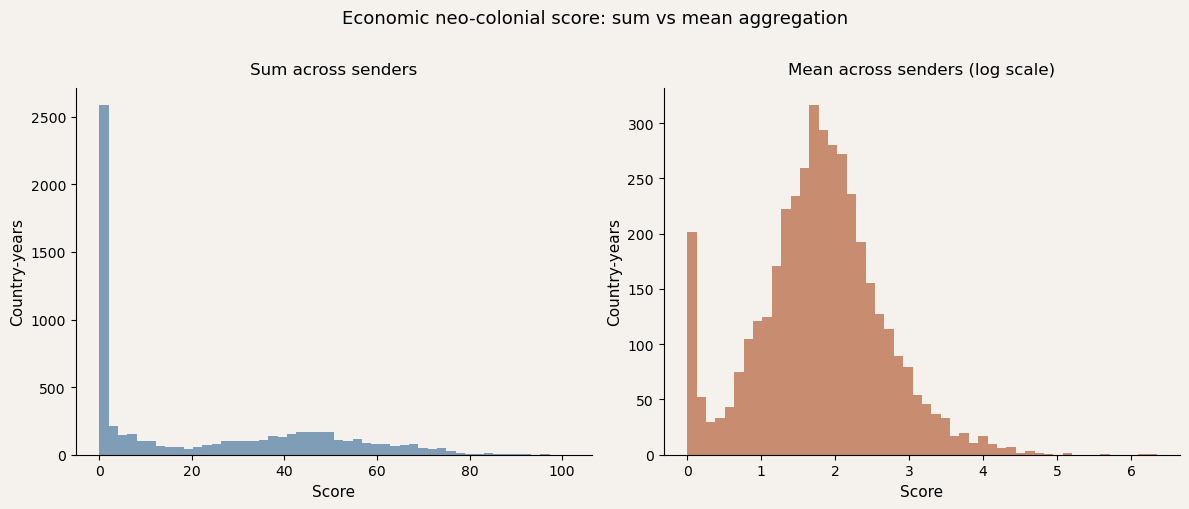

Saved: ../outputs/limitations/econ_score_sum_vs_mean.png


In [12]:
# Side-by-side distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(CREAM)

for ax, col, label, color in zip(
    axes,
    ['econ_neocol_score_total', 'econ_neocol_score_mean'],
    ['Sum across senders', 'Mean across senders (log scale)'],
    MUTED
):
    vals = panel[col].dropna()
    ax.hist(vals, bins=50, color=color, alpha=0.85, edgecolor='none')
    ax.set_xlabel('Score', fontsize=11)
    ax.set_ylabel('Country-years', fontsize=11)
    ax.set_title(label, fontsize=12, pad=10)
    ax.set_facecolor(CREAM)
    ax.tick_params(labelsize=10)

fig.suptitle('Economic neo-colonial score: sum vs mean aggregation', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/limitations/econ_score_sum_vs_mean.png', dpi=150, bbox_inches='tight',
            facecolor=CREAM)
plt.show()
print('Saved: ../outputs/limitations/econ_score_sum_vs_mean.png')

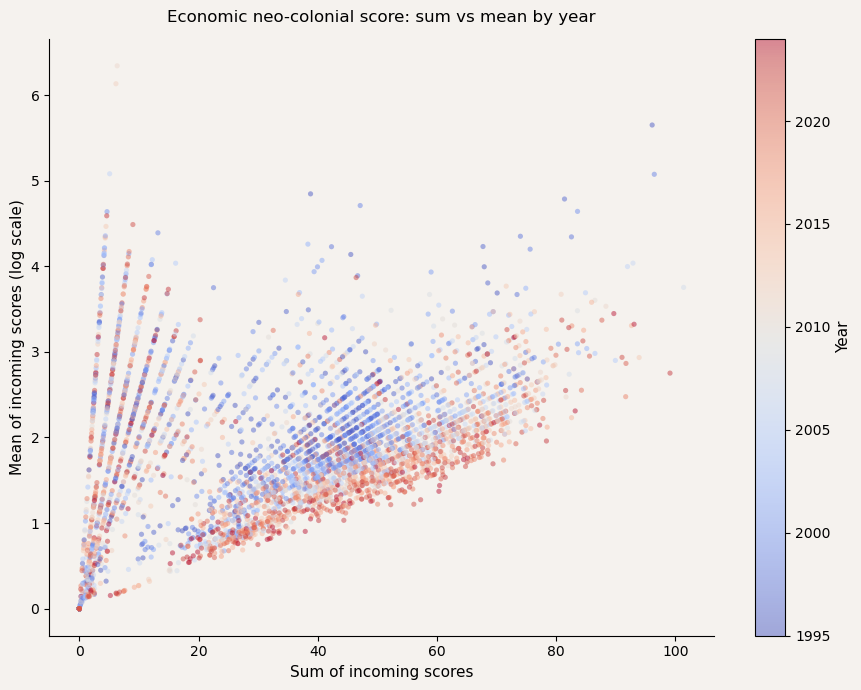

Saved: ../outputs/limitations/econ_score_sum_vs_mean_scatter.png


In [13]:
# Scatter: sum vs mean, coloured by year
scatter_df = panel[['econ_neocol_score_total', 'econ_neocol_score_mean', 'year']].dropna()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor(CREAM)
ax.set_facecolor(CREAM)

sc = ax.scatter(
    scatter_df['econ_neocol_score_total'],
    scatter_df['econ_neocol_score_mean'],
    c=scatter_df['year'],
    cmap='coolwarm',
    alpha=0.45,
    s=14,
    linewidths=0
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Year', fontsize=11)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

ax.set_xlabel('Sum of incoming scores', fontsize=11)
ax.set_ylabel('Mean of incoming scores (log scale)', fontsize=11)
ax.set_title('Economic neo-colonial score: sum vs mean by year', fontsize=12, pad=12)
ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/limitations/econ_score_sum_vs_mean_scatter.png', dpi=150,
            bbox_inches='tight', facecolor=CREAM)
plt.show()
print('Saved: ../outputs/limitations/econ_score_sum_vs_mean_scatter.png')

## Part 3 — Save Enriched Panel

In [14]:
out_path = '../data/merged/panel_monadic_enriched_1992_2024.csv'
panel.to_csv(out_path, index=False)

print(f'Saved: {out_path}')
print(f'Shape: {panel.shape}')
print(f'Columns ({len(panel.columns)}):')
for col in panel.columns:
    print(f'  {col}')

Saved: ../data/merged/panel_monadic_enriched_1992_2024.csv
Shape: (6358, 15)
Columns (15):
  recipient_iso3
  year
  arms_tiv_total
  oda_total
  econ_neocol_score_total
  colonial_tie_flag
  journalist_killings
  gdp_per_capita
  gdp_per_capita_log
  population
  population_log
  armed_conflict
  conflict_intensity
  arms_tiv_stock_5yr
  econ_neocol_score_mean
